# ใบงานที่ 3 Regression & Classification 

## จัดทำโดยนายปัญญพัฒน์ รักษาบุญ 116710400566-1 sec2 + AI claude ai

## ขั้นที่ 1: Import Library + ตั้งค่าตัวแปรหลัก
นำเข้าไลบรารีที่ใช้ทั้งหมด (OpenCV, NumPy, Pandas, Matplotlib, scikit-learn) และตั้งค่าตัวแปรหลัก เช่น path ของข้อมูล ขนาดภาพ จำนวนตัวอย่างที่จะใช้ ไว้ที่เดียวเพื่อแก้ไขง่าย

In [ ]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

## อันนี้จะเป็นการเลือกรูปภาพจาก dataset UTKFace มา 4000 รูปภาพ โดยจะทำการ resize รูปภาพให้มีขนาด 64x64 และเก็บข้อมูลอายุและเพศของแต่ละรูปภาพไว้ใน list ที่เลือกแค่นี้เพราะว่าคอมกากครับ
DATA_DIR = r"data/UTKFace"  
IMG_SIZE = 64
N_SAMPLES = 4000
RANDOM_STATE = 42

## ขั้นที่ 2: สุ่มเลือกไฟล์ + โหลดภาพ + ดึง Label จากชื่อไฟล์
สุ่มเลือกชื่อไฟล์ 4,000 ไฟล์แบบไม่ซ้ำ (กำหนด seed เพื่อให้ผลลัพธ์ทำซ้ำได้) จากนั้นอ่านภาพและแกะค่าอายุ/เพศจากชื่อไฟล์เก็บเป็นชุดข้อมูล

In [11]:
all_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".jpg")]
print("มีทั้งหมด:", len(all_files), "ไฟล์")

random.seed(RANDOM_STATE)
selected_files = random.sample(all_files, min(N_SAMPLES, len(all_files)))
print("สุ่มมาใช้:", len(selected_files), "ไฟล์")

images = []
ages = []
genders = []

for fname in selected_files:
    try:
        parts = fname.split("_")
        age = int(parts[0])
        gender = int(parts[1])   # 0 = ชาย, 1 = หญิง
    except (ValueError, IndexError):
        continue  # ข้ามไฟล์ชื่อไม่ตรง format

    img_path = os.path.join(DATA_DIR, fname)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    images.append(img)
    ages.append(age)
    genders.append(gender)

print(f"โหลดภาพสำเร็จ: {len(images)} ภาพ")

มีทั้งหมด: 9884 ไฟล์
สุ่มมาใช้: 4000 ไฟล์
โหลดภาพสำเร็จ: 4000 ภาพ


## ขั้นที่ 3: Preprocessing (Flatten + Normalize)
แปลงภาพ 64x64 พิกเซลให้เป็นเวกเตอร์ 1 มิติ (4,096 ค่า) และปรับค่าพิกเซลให้อยู่ในช่วง 0-1 เพื่อให้โมเดลเรียนรู้ได้อย่างมีประสิทธิภาพ

In [12]:
X = np.array(images).reshape(len(images), -1).astype("float32") / 255.0
y_age = np.array(ages)
y_gender = np.array(genders)

print("X shape:", X.shape)
print("y_age shape:", y_age.shape)
print("y_gender shape:", y_gender.shape)

X shape: (4000, 4096)
y_age shape: (4000,)
y_gender shape: (4000,)


#### ข้อมูลที่สุ่มมามีการกระจายตัวไม่สม่ำเสมอ โดยกลุ่มอายุ 20-30 ปีมีจำนวนภาพมากที่สุด ขณะที่กลุ่มผู้สูงอายุ (60 ปีขึ้นไป) มีจำนวนภาพน้อยมาก อาจส่งผลให้โมเดล Regression ทำนายอายุในช่วงวัยที่มีข้อมูลน้อยได้แม่นยำต่ำกว่าช่วงวัยที่มีข้อมูลเยอะ

อายุน้อยสุด: 1
อายุมากสุด: 116
อายุเฉลี่ย: 21.16125


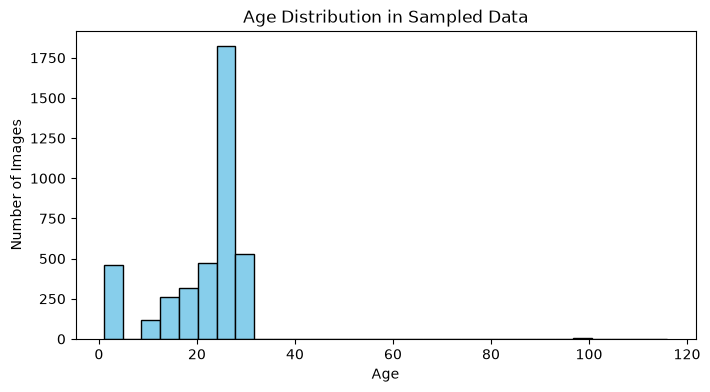

In [13]:
print("อายุน้อยสุด:", y_age.min())
print("อายุมากสุด:", y_age.max())
print("อายุเฉลี่ย:", y_age.mean())

plt.figure(figsize=(8, 4))
plt.hist(y_age, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Images")
plt.title("Age Distribution in Sampled Data")
plt.show()

## ขั้นที่ 4: แบ่ง Train/Test
แบ่งข้อมูลเป็น Training set (80%) และ Testing set (20%) เพื่อใช้สอนโมเดลและประเมินผลบนข้อมูลที่โมเดลไม่เคยเห็นมาก่อน ป้องกันปัญหา Overfitting

In [14]:
X_train, X_test, age_train, age_test, gender_train, gender_test = train_test_split(
    X, y_age, y_gender, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (3200, 4096)  Test: (800, 4096)


## ขั้นที่ 5: PCA ลดจำนวนคุณลักษณะ
ใช้ Principal Component Analysis (PCA) ลดมิติของข้อมูลจาก 4,096 ฟีเจอร์ เหลือ 50 ฟีเจอร์ โดยยังคงรักษาความแปรปรวนของข้อมูลไว้ได้ประมาณ 88.8%

In [15]:
pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("อธิบาย variance รวมได้:", pca.explained_variance_ratio_.sum())
print("X_train_pca shape:", X_train_pca.shape)

อธิบาย variance รวมได้: 0.8883053
X_train_pca shape: (3200, 50)


# LAB1: Regression (ทำนายอายุ)

## ขั้นที่ 6: Simple Linear Regression
สร้างโมเดลถดถอยเชิงเส้นอย่างง่าย โดยใช้เพียง 1 คุณลักษณะ (PCA component แรก) ในการทำนายอายุ

In [16]:
simple_reg = LinearRegression()
simple_reg.fit(X_train_pca[:, [0]], age_train)

age_pred_train_simple = simple_reg.predict(X_train_pca[:, [0]])
age_pred_test_simple  = simple_reg.predict(X_test_pca[:, [0]])

## ขั้นที่ 7: Multiple Linear Regression
สร้างโมเดลถดถอยเชิงเส้นแบบพหุคูณ โดยใช้คุณลักษณะทั้งหมด 50 ตัวจาก PCA ในการทำนายอายุ

In [17]:
multi_reg = LinearRegression()
multi_reg.fit(X_train_pca, age_train)

age_pred_train_multi = multi_reg.predict(X_train_pca)
age_pred_test_multi  = multi_reg.predict(X_test_pca)

## ขั้นที่ 8: ประเมินผล Regression
วัดประสิทธิภาพของทั้งสองโมเดลด้วย MAE, MSE และ R² เปรียบเทียบผลระหว่าง Training set และ Testing set

In [35]:
# เก็บผลลัพธ์เป็นตารางแทนการ print แยกทีละบรรทัด
reg_results = pd.DataFrame({
    "Model": ["Simple Linear Reg", "Simple Linear Reg",
              "Multiple Linear Reg", "Multiple Linear Reg"],
    "Set": ["Train", "Test", "Train", "Test"],
    "MAE": [
        mean_absolute_error(age_train, age_pred_train_simple),
        mean_absolute_error(age_test,  age_pred_test_simple),
        mean_absolute_error(age_train, age_pred_train_multi),
        mean_absolute_error(age_test,  age_pred_test_multi),
    ],
    "MSE": [
        mean_squared_error(age_train, age_pred_train_simple),
        mean_squared_error(age_test,  age_pred_test_simple),
        mean_squared_error(age_train, age_pred_train_multi),
        mean_squared_error(age_test,  age_pred_test_multi),
    ],
    "R2": [
        r2_score(age_train, age_pred_train_simple),
        r2_score(age_test,  age_pred_test_simple),
        r2_score(age_train, age_pred_train_multi),
        r2_score(age_test,  age_pred_test_multi),
    ],
})

display(
    reg_results.style
        .format({"MAE": "{:.2f}", "MSE": "{:.2f}", "R2": "{:.3f}"})
        .background_gradient(subset=["MAE", "MSE"], cmap="Reds")
        .background_gradient(subset=["R2"], cmap="Greens")
        .set_caption("LAB1: Regression Evaluation - Age Prediction")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "caption",
                             "props": [("font-size", "14px"),
                                       ("font-weight", "bold")]}])
)

,Model,Set,MAE,MSE,R2
0,Simple Linear Reg,Train,6.10,75.92,0.147
1,Simple Linear Reg,Test,5.66,61.89,0.147
2,Multiple Linear Reg,Train,4.86,52.31,0.412
3,Multiple Linear Reg,Test,4.59,41.31,0.430


# LAB2: Classification (ทำนายเพศ)

## ขั้นที่ 9: Decision Boundary Visualization
แสดงภาพขอบเขตการตัดสินใจ (Decision Boundary) ของโมเดล Logistic Regression โดยใช้ PCA เพียง 2 มิติแรก เพื่อให้เห็นภาพการแบ่งกลุ่มข้อมูล
จากภาพ Decision Boundary ที่ใช้เพียง 2 องค์ประกอบหลักจาก PCA (PC1, PC2) พบว่าข้อมูลของทั้งสองเพศมีการปะปนกันมาก แสดงว่ามิติทั้งสองนี้ไม่เพียงพอต่อการแยกเพศได้อย่างชัดเจน เนื่องจาก PC1-PC2 อาจสะท้อนความแปรปรวนด้านอายุหรือแสงมากกว่าเพศ ดังนั้นในขั้นถัดไปจึงใช้ PCA ทั้ง 50 มิติ (Logistic Regression เต็มรูปแบบ) เพื่อให้แยกเพศได้แม่นยำขึ้น

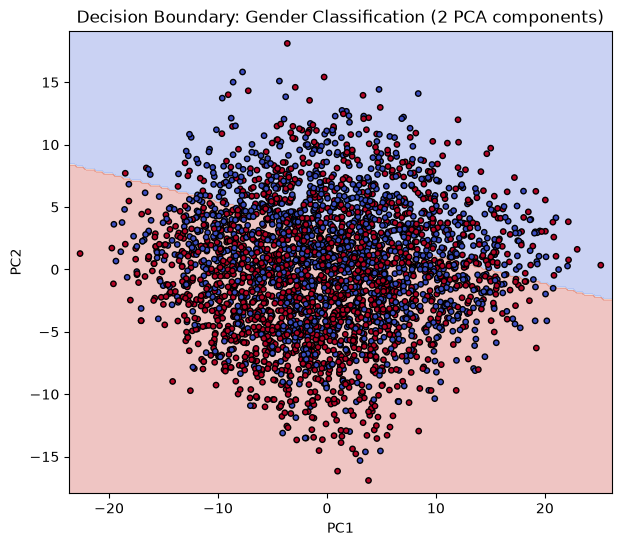

In [19]:
clf_2d = LogisticRegression(max_iter=1000)
clf_2d.fit(X_train_pca[:, :2], gender_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=gender_train,
            cmap="coolwarm", edgecolor="k", s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary: Gender Classification (2 PCA components)")
plt.show()

## ขั้นที่ 10: Logistic Regression
สร้างโมเดล Logistic Regression โดยใช้คุณลักษณะทั้งหมด 50 ตัวจาก PCA เพื่อทำนายเพศให้มีความแม่นยำสูงสุด

In [21]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_pca, gender_train)

gender_pred_train = clf.predict(X_train_pca)
gender_pred_test  = clf.predict(X_test_pca)
gender_proba_test = clf.predict_proba(X_test_pca)[:, 1]

## ขั้นที่ 11: Confusion Matrix และตัวชี้วัดการจำแนกประเภท
ประเมินผลโมเดลด้วย Confusion Matrix, Accuracy, Precision, Recall และ F1-score เพื่อวิเคราะห์ความสามารถในการจำแนกเพศของโมเดล
โมเดล Logistic Regression ที่ใช้ PCA 50 มิติ ให้ผล Accuracy บน Test set ที่ 79.4% ซึ่งใกล้เคียงกับ Train set (81.0%) แสดงว่าโมเดลไม่เกิด overfitting จาก Confusion Matrix พบว่าโมเดลทำนายเพศหญิงได้แม่นยำกว่าเพศชายเล็กน้อย 
อ่าน Confusion Matrix
	ทายว่า Male	ทายว่า Female
จริงเป็น Male	262 (ถูก)	97 (ผิด)
จริงเป็น Female	68 (ผิด)	373 (ถูก)

[Gender - Train] Acc=0.810  Precision=0.817  Recall=0.847  F1=0.832
[Gender - Test] Acc=0.794  Precision=0.794  Recall=0.846  F1=0.819


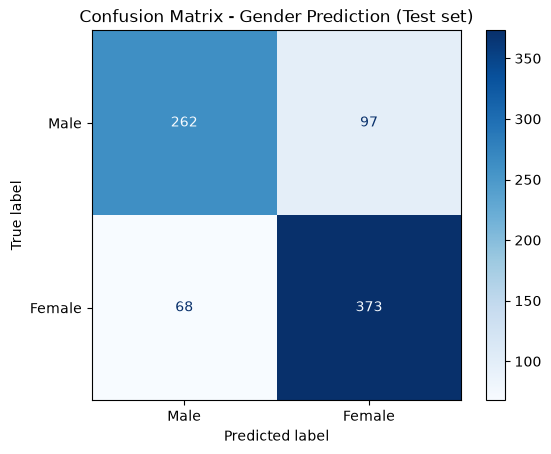

In [22]:
def eval_classification(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"[{name}] Acc={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    return acc, prec, rec, f1

eval_classification(gender_train, gender_pred_train, "Gender - Train")
eval_classification(gender_test,  gender_pred_test,  "Gender - Test")

cm = confusion_matrix(gender_test, gender_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Male", "Female"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Gender Prediction (Test set)")
plt.show()

## ขั้นที่ 12: ROC Curve และ AUC
วิเคราะห์ประสิทธิภาพของโมเดลด้วย ROC Curve และค่า AUC เพื่อประเมินความสามารถในการแยกแยะระหว่างสองคลาส

ค่า AUC ที่ได้เท่ากับ 0.874 อยู่ในเกณฑ์ดี แสดงว่าโมเดล Logistic Regression สามารถแยกแยะระหว่างเพศชายและหญิงได้อย่างมีประสิทธิภาพ โดยมีความสามารถในการจำแนกสูงกว่าการทายแบบสุ่มอย่างชัดเจน

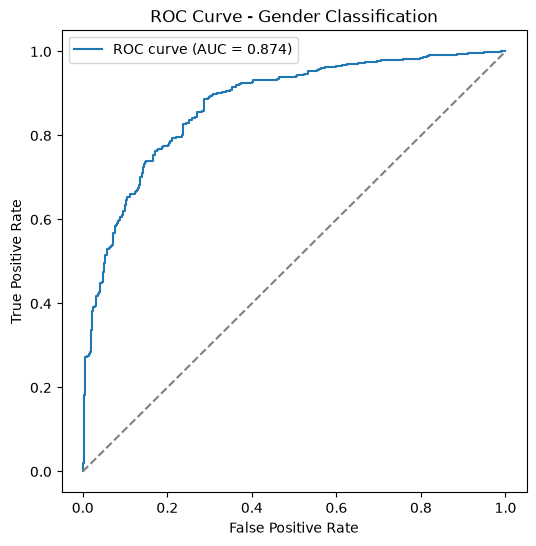

AUC = 0.874
อยู่ในขั้นที่ดี loveyou อิอิอิอิ


In [27]:
fpr, tpr, thresholds = roc_curve(gender_test, gender_proba_test)
auc_score = roc_auc_score(gender_test, gender_proba_test)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gender Classification")
plt.legend()
plt.show()

print(f"AUC = {auc_score:.3f}")
print(f"อยู่ในขั้นที่ดี loveyou อิอิอิอิ")

# LAB3: Model Comparison

## ขั้นที่ 13: สรุปตารางเปรียบเทียบผลลัพธ์
รวบรวมผลลัพธ์ทั้งหมดเป็นตาราง เปรียบเทียบ Simple vs Multiple Regression, Training vs Testing Performance และ Regression vs Classification เพื่อสรุปภาพรวมของแบบจำลองทั้งหมด

จากผลการทดลอง โมเดล Classification (ทำนายเพศ) ให้ผลลัพธ์ที่แม่นยำและเสถียรกว่าโมเดล Regression (ทำนายอายุ) อย่างชัดเจน โดย Classification มี Accuracy สูงถึง ~79-81% ขณะที่ Regression มีค่า R² เพียง ~0.43 ทั้งนี้เนื่องจากงานทำนายเพศเป็นปัญหาสองทางเลือก (Binary) ในขณะที่การทำนายอายุเป็นค่าต่อเนื่องที่มีความหลากหลายสูง ประกอบกับข้อมูลอายุที่ใช้มีการกระจายตัวไม่สม่ำเสมอ (กลุ่มอายุน้อยมีจำนวนมากกว่ากลุ่มผู้สูงอายุ) ส่งผลให้โมเดล Regression เรียนรู้ได้ไม่เต็มประสิทธิภาพเท่ากับ Classification

In [30]:
comparison = pd.DataFrame({
    "Model": ["Simple Linear Reg (Train)", "Simple Linear Reg (Test)",
              "Multiple Linear Reg (Train)", "Multiple Linear Reg (Test)"],
    "MAE": [
        mean_absolute_error(age_train, age_pred_train_simple),
        mean_absolute_error(age_test,  age_pred_test_simple),
        mean_absolute_error(age_train, age_pred_train_multi),
        mean_absolute_error(age_test,  age_pred_test_multi),
    ],
    "MSE": [
        mean_squared_error(age_train, age_pred_train_simple),
        mean_squared_error(age_test,  age_pred_test_simple),
        mean_squared_error(age_train, age_pred_train_multi),
        mean_squared_error(age_test,  age_pred_test_multi),
    ],
    "R2": [
        r2_score(age_train, age_pred_train_simple),
        r2_score(age_test,  age_pred_test_simple),
        r2_score(age_train, age_pred_train_multi),
        r2_score(age_test,  age_pred_test_multi),
    ],
})


gender_comparison = pd.DataFrame({
    "Set": ["Train", "Test"],
    "Accuracy": [accuracy_score(gender_train, gender_pred_train),
                 accuracy_score(gender_test, gender_pred_test)],
    "Precision": [precision_score(gender_train, gender_pred_train),
                  precision_score(gender_test, gender_pred_test)],
    "Recall": [recall_score(gender_train, gender_pred_train),
               recall_score(gender_test, gender_pred_test)],
    "F1": [f1_score(gender_train, gender_pred_train),
           f1_score(gender_test, gender_pred_test)],
})


print("=== ตารางที่ 1: Regression Comparison (ทำนายอายุ) ===")
display(
    comparison.style
        .format({"MAE": "{:.2f}", "MSE": "{:.2f}", "R2": "{:.3f}"})
        .background_gradient(subset=["MAE", "MSE"], cmap="Reds")
        .background_gradient(subset=["R2"], cmap="Greens")
        .set_caption("Regression: Simple vs Multiple Linear Regression")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "caption",
                             "props": [("font-size", "14px"),
                                       ("font-weight", "bold")]}])
)

print("\n=== ตารางที่ 2: Classification Comparison (ทำนายเพศ) ===")
display(
    gender_comparison.style
        .format({"Accuracy": "{:.3f}", "Precision": "{:.3f}",
                 "Recall": "{:.3f}", "F1": "{:.3f}"})
        .background_gradient(subset=["Accuracy", "Precision", "Recall", "F1"], cmap="Blues")
        .set_caption("Classification: Gender Prediction (Train vs Test)")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "caption",
                             "props": [("font-size", "14px"),
                                       ("font-weight", "bold")]}])
)

=== ตารางที่ 1: Regression Comparison (ทำนายอายุ) ===


,Model,MAE,MSE,R2
0,Simple Linear Reg (Train),6.10,75.92,0.147
1,Simple Linear Reg (Test),5.66,61.89,0.147
2,Multiple Linear Reg (Train),4.86,52.31,0.412
3,Multiple Linear Reg (Test),4.59,41.31,0.430



=== ตารางที่ 2: Classification Comparison (ทำนายเพศ) ===


,Set,Accuracy,Precision,Recall,F1
0,Train,0.810,0.817,0.847,0.832
1,Test,0.794,0.794,0.846,0.819


# อันนี้จะลองสุ่ม จะเห็นได้ว่าเป็นการสุ่มแบบสม่ำเสมอ (uniform random) ให้ภาพรวมของข้อมูลที่คล้ายกัน แม้จะสุ่มคนละชุดก็ตาม

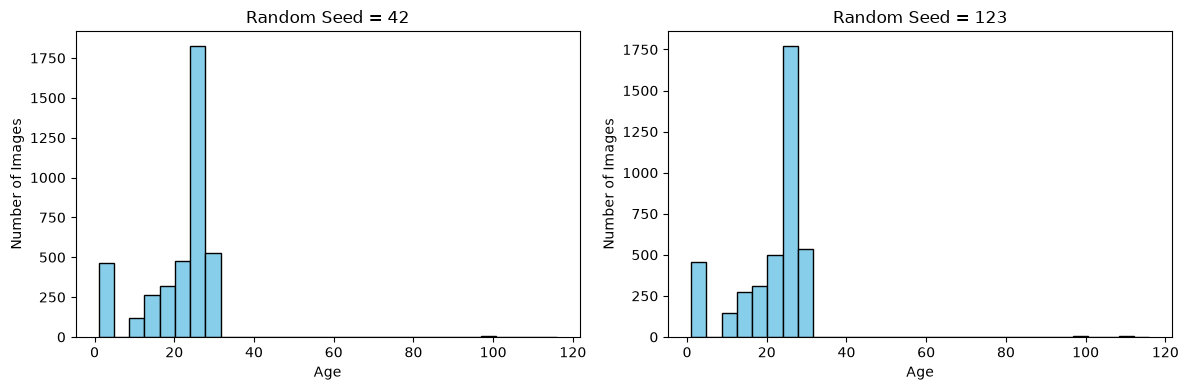

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, seed in enumerate([42, 123]):
    random.seed(seed)
    files_demo = random.sample(all_files, N_SAMPLES)
    ages_demo = [int(f.split("_")[0]) for f in files_demo 
                 if f.split("_")[0].isdigit()]
    
    axes[i].hist(ages_demo, bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(f"Random Seed = {seed}")
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()